# SMS Spam Detection: A Comparative NLP Study
---
## Overview
This notebook compares five NLP models for binary SMS spam classification using the UCI SMS Spam Collection dataset.
### Models
| # | Model | Type |
|---|-------|------|
| 1 | **SVM** | Traditional ML |
| 2 | **TextCNN** | Deep Learning |
| 3 | **Bi-GRU** | Deep Learning |
| 4 | **DistilBERT** | Transformer |
| 5 | **RoBERTa** | Transformer |
### Dataset
- **Source**: UCI SMS Spam Collection — 5,572 messages, ~13.4% spam
### Evaluation Metrics
- **MCC** — robust to class imbalance
- **PR-AUC** — precision-recall area under curve
- **F1-Score** — harmonic mean of precision and recall


---
## Section 1 — Environment Setup
Install dependencies and configure global settings. GPU/MPS is auto-detected for transformer acceleration.


In [1]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "numpy", "pandas", "scikit-learn",
    "torch", "transformers",
    "matplotlib", "seaborn", "tqdm", "nltk", "requests"
], check=True)
print("Installation complete.")

Installation complete.


In [2]:
import os, re, copy, json, zipfile, warnings, time, pickle
import requests
from collections import Counter
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    matthews_corrcoef, f1_score, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.notebook import tqdm

from transformers import AutoTokenizer, DistilBertModel, RobertaModel

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR        = "data"
RESULTS_DIR     = "results"
GLOVE_PATH      = os.path.join(DATA_DIR, "glove.6B.100d.txt")
MAX_VOCAB       = 20_000
MAX_SEQ_LEN     = 128
TRANSFORMER_LEN = 128
TEST_SIZE       = 0.40          # 60/40 split
VAL_FRAC        = 0.10          # 10% of train → internal validation
STOP_WORDS      = set(stopwords.words("english"))
PALETTE = {
    "SVM":"#4C6EF5", "TextCNN":"#F76707",
    "Bi-GRU":"#2F9E44", "DistilBERT":"#AE3EC9", "RoBERTa":"#E03131"
}

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"  PyTorch : {torch.__version__}")
print(f"  Device  : {DEVICE}")
print("  All imports successful.")

  PyTorch : 2.11.0
  Device  : mps
  All imports successful.


In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

---
## Section 2 — Dataset Loading & Exploratory Data Analysis

The **UCI SMS Spam Collection** is auto-downloaded from the UCI ML Repository. It contains 5,572 English SMS messages labelled `ham` or `spam`.

EDA examines:
- **Class distribution** — confirms the ~13.4% spam imbalance that motivates weighted training strategies
- **Message length** — spam messages tend to be longer (more promotional content)
- **Sample messages** — illustrates informal language, abbreviations, and spam patterns

In [4]:
UCI_URL  = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
            "/00228/smsspamcollection.zip")
RAW_FILE = os.path.join(DATA_DIR, "SMSSpamCollection")

def download_dataset():
    if os.path.exists(RAW_FILE):
        print(f"Dataset present: {RAW_FILE}")
        return
    print("Downloading UCI SMS Spam Collection ...")
    zip_path = os.path.join(DATA_DIR, "tmp.zip")
    r = requests.get(UCI_URL, timeout=30)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    os.remove(zip_path)
    print(f"Saved to: {RAW_FILE}")

download_dataset()

df = pd.read_csv(
    RAW_FILE, sep="\t", header=None,
    names=["label", "text"], encoding="latin-1"
)
df["label_int"]  = (df["label"] == "spam").astype(int)
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

spam = df["label_int"].sum()
ham  = (df["label_int"] == 0).sum()
print(f"\nTotal   : {len(df):,}")
print(f"Spam    : {spam:,}  ({spam/len(df)*100:.1f}%)")
print(f"Ham     : {ham:,}  ({ham/len(df)*100:.1f}%)")
df.head(6)

Dataset present: data/SMSSpamCollection

Total   : 5,572
Spam    : 747  (13.4%)
Ham     : 4,825  (86.6%)


,label,text,label_int,char_count,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20
1,ham,Ok lar... Joking wif u oni...,0,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28
3,ham,U dun say so early hor... U c already then say...,0,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1,148,32


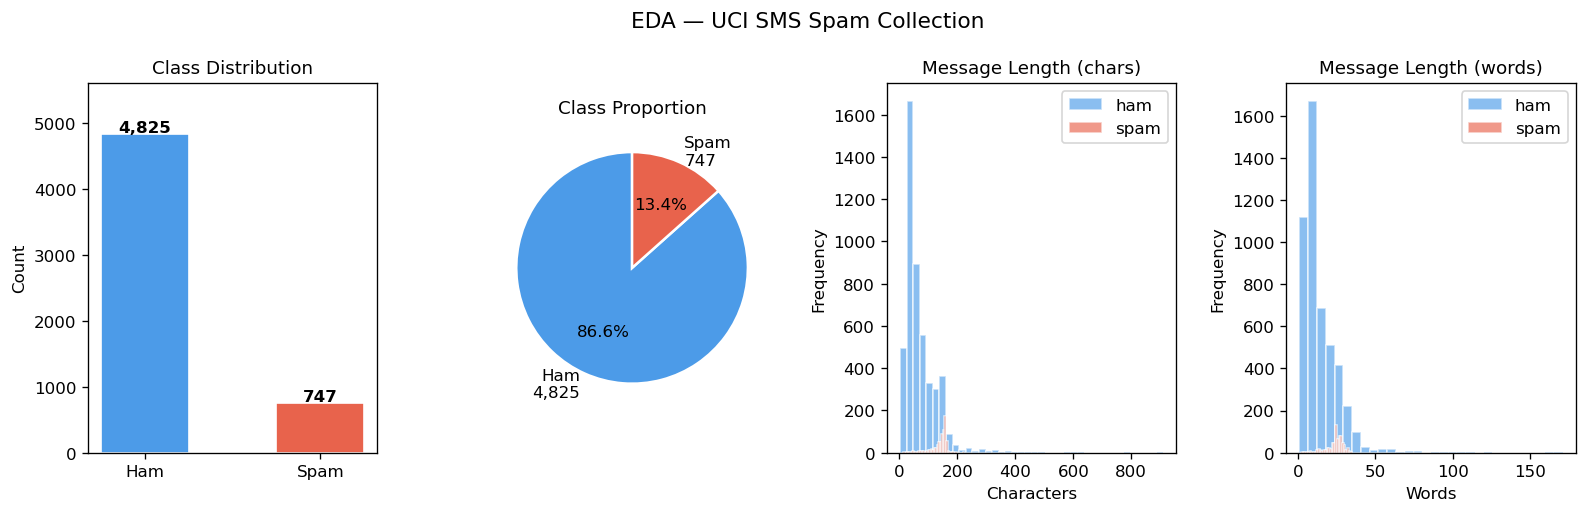

In [5]:
COLORS = {"ham": "#4C9BE8", "spam": "#E8634C"}
counts = df["label"].value_counts()

fig = plt.figure(figsize=(16, 4))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.38)
ax0, ax1, ax2, ax3 = [fig.add_subplot(gs[i]) for i in range(4)]

# Class count
bars = ax0.bar(["Ham", "Spam"], [counts["ham"], counts["spam"]],
               color=[COLORS["ham"], COLORS["spam"]], width=0.5, edgecolor="white")
for b in bars:
    ax0.text(b.get_x()+b.get_width()/2, b.get_height()+40,
             f"{int(b.get_height()):,}", ha="center", fontsize=10, fontweight="bold")
ax0.set_title("Class Distribution", fontsize=11)
ax0.set_ylabel("Count"); ax0.set_ylim(0, 5600)

# Proportion pie
ax1.pie([counts["ham"], counts["spam"]],
        labels=[f"Ham\n{counts['ham']:,}", f"Spam\n{counts['spam']}"],
        colors=[COLORS["ham"], COLORS["spam"]],
        autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax1.set_title("Class Proportion", fontsize=11)

# Character length distribution
for lbl, c in COLORS.items():
    ax2.hist(df[df["label"]==lbl]["char_count"], bins=40,
             alpha=0.65, label=lbl, color=c, edgecolor="white")
ax2.set_title("Message Length (chars)", fontsize=11)
ax2.set_xlabel("Characters"); ax2.set_ylabel("Frequency"); ax2.legend()

# Word count distribution
for lbl, c in COLORS.items():
    ax3.hist(df[df["label"]==lbl]["word_count"], bins=30,
             alpha=0.65, label=lbl, color=c, edgecolor="white")
ax3.set_title("Message Length (words)", fontsize=11)
ax3.set_xlabel("Words"); ax3.set_ylabel("Frequency"); ax3.legend()

fig.suptitle("EDA — UCI SMS Spam Collection", fontsize=13, y=1.03)
plt.savefig(os.path.join(RESULTS_DIR, "01_eda.png"), dpi=120, bbox_inches="tight")
plt.show()

In [6]:
print("Descriptive statistics:")
print(df.groupby("label")[["char_count","word_count"]].describe().round(1).to_string())

print("\n── Sample HAM messages ──")
for msg in df[df["label"]=="ham"]["text"].sample(3, random_state=SEED).values:
    print(f"  [{len(msg):3d} chars]  {msg[:95]}")

print("\n── Sample SPAM messages ──")
for msg in df[df["label"]=="spam"]["text"].sample(3, random_state=SEED).values:
    print(f"  [{len(msg):3d} chars]  {msg[:95]}")

Descriptive statistics:
      char_count                                                word_count                                          
           count   mean   std   min    25%    50%    75%    max      count  mean   std  min   25%   50%   75%    max
label                                                                                                               
ham       4825.0   71.6  58.5   2.0   33.0   52.0   93.0  910.0     4825.0  14.3  11.5  1.0   7.0  11.0  19.0  171.0
spam       747.0  139.1  29.0  13.0  133.0  149.0  158.0  224.0      747.0  23.9   5.8  2.0  22.0  25.0  28.0   35.0

── Sample HAM messages ──
  [ 86 chars]  If i not meeting Ã¼ all rite then i'll go home lor. If Ã¼ dun feel like comin it's ok.
  [103 chars]  I.ll always be there, even if its just in spirit. I.ll get a bb soon. Just trying to be sure i 
  [ 32 chars]  Sorry that took so long, omw now

── Sample SPAM messages ──
  [159 chars]  Summers finally here! Fancy a chat or flirt with sexy single

---
## Section 3 — Text Preprocessing
A lightweight cleaning pipeline is applied uniformly to all models: lowercasing, URL/email/phone normalization, punctuation removal, and whitespace collapsing. SVM additionally removes stopwords for TF-IDF.


In [7]:
def clean_text(text: str, remove_stopwords: bool = False) -> str:
    """
    Universal text cleaning pipeline.
    Steps 1-6 applied to all models.
    Step 7 (stopword removal) used only for SVM TF-IDF pipeline.
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+",  " url ",   text)   # step 2
    text = re.sub(r"\S+@\S+",          " email ", text)   # step 3
    text = re.sub(r"\b\d{10,}\b",      " phone ", text)   # step 4
    text = re.sub(r"[^a-z0-9\s]",      " ",       text)   # step 5
    text = re.sub(r"\s+",              " ",       text).strip()  # step 6
    if remove_stopwords:                                   # step 7
        text = " ".join(w for w in text.split() if w not in STOP_WORDS)
    return text

demo = [
    "FREE entry in 2 a wkly comp to win FA Cup tkts! Text FA to 87121 to receive",
    "Ok lar... Joking wif u oni...",
    "WINNER!! Selected 2 receivea prize! Call 09061701461 or visit www.win.co.uk",
]
print(f"{'Original (truncated)':<55}  {'Cleaned':<55}")
for ex in demo:
    print(f"{ex[:53]:<55}  {clean_text(ex)[:53]:<55}")

df["text_clean"] = df["text"].apply(clean_text)
print("\nCleaned text column added to DataFrame.")

Original (truncated)                                     Cleaned                                                
FREE entry in 2 a wkly comp to win FA Cup tkts! Text     free entry in 2 a wkly comp to win fa cup tkts text f  
Ok lar... Joking wif u oni...                            ok lar joking wif u oni                                
WINNER!! Selected 2 receivea prize! Call 09061701461     winner selected 2 receivea prize call phone or visit   

Cleaned text column added to DataFrame.


---
## Section 4 — Data Splitting & Shared Utilities
### Split Strategy
```
Full dataset (5,572)
   ├── Test set   : 40% — held out, never used during training
   └── Train+Val  : 60%
            ├── Train  : 90% of 60% = 54% overall
            └── Val    : 10% of 60% =  6% overall — internal only
```
All splits are **stratified** to preserve class distribution. Class imbalance is handled via inverse-frequency weighting.


In [8]:
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE,
    stratify=df["label_int"], random_state=SEED
)
train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FRAC,
    stratify=train_val_df["label_int"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

y_train = train_df["label_int"].values
y_val   = val_df["label_int"].values
y_test  = test_df["label_int"].values

for name, part, y in [("Train (54%)", train_df, y_train),
                      ("Val   ( 6%)", val_df,   y_val),
                      ("Test  (40%)", test_df,  y_test)]:
    print(f"  {name}: {len(part):>5} msgs | "
          f"spam={y.sum():>3} ({y.mean()*100:.1f}%) | "
          f"ham={(y==0).sum():>4}")

  Train (54%):  3008 msgs | spam=403 (13.4%) | ham=2605
  Val   ( 6%):   335 msgs | spam= 45 (13.4%) | ham= 290
  Test  (40%):  2229 msgs | spam=299 (13.4%) | ham=1930


In [9]:
#
# ngram_range=(1,2) : unigrams + bigrams capture "free entry", "win prize"
# max_features=10000: top 10,000 n-gram features
# sublinear_tf=True : replace raw TF with 1+log(TF) to dampen frequent terms
#
# Vectoriser fit on training set ONLY — prevents leakage into val/test.
# Stopwords removed for SVM to reduce noise in high-dimensional TF-IDF space.

tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1,2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(
    train_df["text"].apply(lambda t: clean_text(t, remove_stopwords=True))
)
X_val_tfidf   = tfidf.transform(
    val_df["text"].apply(lambda t: clean_text(t, remove_stopwords=True))
)
X_test_tfidf  = tfidf.transform(
    test_df["text"].apply(lambda t: clean_text(t, remove_stopwords=True))
)

print(f"TF-IDF  train={X_train_tfidf.shape}  "
      f"val={X_val_tfidf.shape}  test={X_test_tfidf.shape}")

TF-IDF  train=(3008, 10000)  val=(335, 10000)  test=(2229, 10000)


In [10]:
#
# index 0 → <PAD>  (padding token; embedding zeroed out)
# index 1 → <UNK>  (out-of-vocabulary words)
# Built from training corpus only.

class Vocabulary:
    PAD = "<PAD>"
    UNK = "<UNK>"

    def __init__(self, max_size=MAX_VOCAB):
        self.max_size = max_size
        self.word2idx = {self.PAD: 0, self.UNK: 1}
        self.idx2word = {0: self.PAD, 1: self.UNK}

    def build(self, texts):
        counts = Counter(w for t in texts for w in t.split())
        for word, _ in counts.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f"  Vocabulary: {len(self.word2idx):,} tokens")
        return self

    def encode(self, text, max_len=MAX_SEQ_LEN):
        tokens = text.split()[:max_len]
        ids    = [self.word2idx.get(w, 1) for w in tokens]
        ids   += [0] * (max_len - len(ids))   # pad
        return ids

    def __len__(self): return len(self.word2idx)

vocab = Vocabulary().build([clean_text(t) for t in train_df["text"].tolist()])

  Vocabulary: 5,946 tokens


In [11]:
#
# GloVe (Pennington et al., 2014) maps vocabulary words to 100-dimensional
# dense vectors trained on 6B tokens. This reduces sparsity by placing
# semantically similar words ("free", "win", "prize") near each other.
# OOV words get small random vectors; <PAD> is fixed at zero.

def load_glove(vocab, path, embed_dim=100):
    emb = np.random.normal(scale=0.1, size=(len(vocab), embed_dim)).astype(np.float32)
    emb[0] = 0.0   # PAD → zero
    if not os.path.exists(path):
        print(f"  [WARNING] GloVe not found at {path}. Using random initialisation.")
        return emb
    loaded = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split()
            if parts[0] in vocab.word2idx:
                emb[vocab.word2idx[parts[0]]] = np.array(parts[1:], dtype=np.float32)
                loaded += 1
    print(f"  GloVe [4]: {loaded}/{len(vocab):,} tokens "
          f"({loaded/len(vocab)*100:.1f}% coverage)")
    return emb

GLOVE_EMB = load_glove(vocab, GLOVE_PATH)

  [WARNING] GloVe not found at data/glove.6B.100d.txt. Using random initialisation.


In [12]:
class SMSDataset(Dataset):
    """Vocab-indexed dataset for TextCNN and Bi-GRU."""
    def __init__(self, texts, labels, vocab, max_len=MAX_SEQ_LEN):
        self.inputs = [
            torch.tensor(vocab.encode(clean_text(t), max_len), dtype=torch.long)
            for t in texts
        ]
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):           return len(self.labels)
    def __getitem__(self, idx):  return self.inputs[idx], self.labels[idx]

class TransformerSMSDataset(Dataset):
    """Subword-tokenised dataset for DistilBERT and RoBERTa."""
    def __init__(self, texts, labels, tokenizer, max_len=TRANSFORMER_LEN):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self):          return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

BATCH_SIZE = 64

def make_dl_loaders(train_df, val_df, test_df, vocab, batch_size=BATCH_SIZE):
    """DataLoaders for TextCNN / Bi-GRU."""
    def _ld(df_, shuffle):
        ds = SMSDataset(df_["text"].tolist(), df_["label_int"].tolist(), vocab)
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
    return _ld(train_df, True), _ld(val_df, False), _ld(test_df, False)

def make_transformer_loaders(train_df, val_df, test_df,
                              tokenizer, batch_size=16):
    """DataLoaders for DistilBERT / RoBERTa."""
    def _ld(df_, shuffle):
        ds = TransformerSMSDataset(
            df_["text"].tolist(), df_["label_int"].tolist(), tokenizer
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
    return _ld(train_df, True), _ld(val_df, False), _ld(test_df, False)

#   w_c = N / (K * n_c)
def compute_class_weights(labels):
    counts  = np.bincount(labels)
    weights = len(labels) / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

CLASS_WEIGHTS = compute_class_weights(y_train)
print(f"Class weights — ham: {CLASS_WEIGHTS[0]:.4f}  |  "
      f"spam: {CLASS_WEIGHTS[1]:.4f}  "
      f"(spam weight is ~{CLASS_WEIGHTS[1]/CLASS_WEIGHTS[0]:.1f}x larger)")

Class weights — ham: 0.5774  |  spam: 3.7320  (spam weight is ~6.5x larger)


In [13]:
#
# Features:
#   - Weighted cross-entropy loss  (addresses class imbalance)
#   - AdamW with weight decay      (regularisation)
#   - Gradient clipping (1.0)      (transformer stability)
#   - ReduceLROnPlateau on val F1  (adaptive learning rate)
#   - Early stopping on val F1     (prevents overfitting)
#   - Best checkpoint restored     (returns epoch with highest val F1)

def _forward(model, batch, is_transformer):
    """Unpack batch and run forward pass. Returns (logits, labels)."""
    if is_transformer:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(ids, attention_mask=mask)
    else:
        inputs, labels = batch
        logits = model(inputs.to(DEVICE))
        labels = labels.to(DEVICE)
    return logits, labels

def train_model(model, train_loader, val_loader,
                epochs=10, lr=1e-3, patience=3, is_transformer=False):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_f1, best_state, no_improve = -1.0, None, 0
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, epochs + 1):
        # Training pass
        model.train()
        total, n = 0.0, 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
            optimizer.zero_grad()
            logits, labels = _forward(model, batch, is_transformer)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item(); n += 1

        # Validation pass
        val_loss, val_f1, _, _ = evaluate_model(model, val_loader,
                                                 criterion, is_transformer)
        scheduler.step(val_f1)
        avg = total / max(n, 1)
        history["train_loss"].append(avg)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        print(f"  Epoch {epoch:02d} | train_loss={avg:.4f} | "
              f"val_loss={val_loss:.4f} | val_F1={val_f1:.4f}")

        # Early stopping
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_state)
    print(f"  Best val F1 = {best_f1:.4f}")
    return model, history

def evaluate_model(model, loader, criterion, is_transformer=False):
    """Inference pass. Returns (avg_loss, f1, y_pred, y_prob)."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            logits, labels = _forward(model, batch, is_transformer)
            total += criterion(logits, labels).item(); n += 1
            probs = torch.softmax(logits, -1)[:, 1].cpu().numpy()
            preds = logits.argmax(-1).cpu().numpy()
            all_probs.extend(probs); all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return total/max(n,1), f1, np.array(all_preds), np.array(all_probs)

def compute_metrics(y_true, y_pred, y_prob=None, name=""):
    mcc    = matthews_corrcoef(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_true, y_prob) if y_prob is not None else None
    if name: print(f"\n[{name} — Test Set]")
    print(f"  MCC    : {mcc:.4f}")
    print(f"  F1     : {f1:.4f}")
    if pr_auc: print(f"  PR-AUC : {pr_auc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["ham","spam"], zero_division=0))
    return {"mcc": mcc, "f1": f1, "pr_auc": pr_auc}

# Result store
ALL_RESULTS = {}
print("Shared utilities defined.")

Shared utilities defined.


---
## Section 5 — Model 1: SVM
Linear SVM with TF-IDF features serves as the traditional ML baseline. Uses `class_weight='balanced'` to handle imbalance and GridSearchCV for hyperparameter selection.


In [14]:
print("  MODEL 1: SVM (LinearSVC + TF-IDF)  [6]")

base_svm = LinearSVC(class_weight="balanced", max_iter=5000, dual=True)
cal_svm  = CalibratedClassifierCV(base_svm, cv=3, method="sigmoid")

gs_svm = GridSearchCV(
    cal_svm,
    param_grid={"estimator__C": [0.01, 0.1, 1.0, 10.0]},
    cv=5, scoring="f1", n_jobs=-1, verbose=1
)
gs_svm.fit(X_train_tfidf, y_train)
svm_model = gs_svm.best_estimator_

print(f"\n  Best C   = {gs_svm.best_params_['estimator__C']}")
print(f"  CV F1    = {gs_svm.best_score_:.4f}")

# Validation check
print("\n  [SVM — Validation]")
svm_val_pred = svm_model.predict(X_val_tfidf)
svm_val_prob = svm_model.predict_proba(X_val_tfidf)[:, 1]
print(f"  Val F1   = {f1_score(y_val, svm_val_pred, zero_division=0):.4f}")

  MODEL 1: SVM (LinearSVC + TF-IDF)  [6]
Fitting 5 folds for each of 4 candidates, totalling 20 fits

  Best C   = 10.0
  CV F1    = 0.9377

  [SVM — Validation]
  Val F1   = 0.9670


In [15]:
svm_y_pred = svm_model.predict(X_test_tfidf)
svm_y_prob = svm_model.predict_proba(X_test_tfidf)[:, 1]
svm_metrics = compute_metrics(y_test, svm_y_pred, svm_y_prob, name="SVM")

ALL_RESULTS["SVM"] = {
    "metrics": svm_metrics, "y_true": y_test,
    "y_pred": svm_y_pred,   "y_prob": svm_y_prob
}
print("SVM results stored.")


[SVM — Test Set]
  MCC    : 0.9187
  F1     : 0.9295
  PR-AUC : 0.9747
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1930
        spam       0.93      0.93      0.93       299

    accuracy                           0.98      2229
   macro avg       0.96      0.96      0.96      2229
weighted avg       0.98      0.98      0.98      2229

SVM results stored.


---
## Section 6 — Model 2: TextCNN
TextCNN uses parallel convolutional filters to capture local n-gram patterns, making it effective for detecting spam-specific surface cues. Initialized with GloVe-100d embeddings.


In [16]:
class TextCNN(nn.Module):
    """
    Kim (2014) TextCNN.
    Each Conv1d filter acts as a learned n-gram detector.
    Parallel filters of widths 2–5 capture bigrams to 5-grams.
    GloVe initialisation reduces sparsity from the start.
    """
    def __init__(self, vocab_size, embed_dim=100, num_classes=2,
                 num_filters=128, filter_sizes=None,
                 dropout=0.5, pretrained_emb=None, freeze_emb=False):
        super().__init__()
        if filter_sizes is None:
            filter_sizes = [2, 3, 4, 5]

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_emb, dtype=torch.float),
                requires_grad=not freeze_emb
            )
        self.convs   = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k)
            for k in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)    # (B, E, L)
        pooled = []
        for conv in self.convs:
            h = F.relu(conv(emb))                    # (B, F, L-k+1)
            h = F.max_pool1d(h, h.size(2)).squeeze(2)  # (B, F)
            pooled.append(h)
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))

print("TextCNN [5] architecture defined.")

TextCNN [5] architecture defined.


### Default Configuration (Pre-Tuning)


In [17]:
print("  MODEL 2: TextCNN  [5]")

cnn_tr, cnn_val, cnn_te = make_dl_loaders(train_df, val_df, test_df, vocab)

textcnn = TextCNN(len(vocab), embed_dim=100, pretrained_emb=GLOVE_EMB)
print(f"  Parameters: {sum(p.numel() for p in textcnn.parameters()):,}")

textcnn, cnn_history = train_model(
    textcnn, cnn_tr, cnn_val,
    epochs=10, lr=1e-3, patience=3, is_transformer=False
)

  MODEL 2: TextCNN  [5]
  Parameters: 775,338


Epoch 1/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.5360 | val_loss=0.2772 | val_F1=0.9231


Epoch 2/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.1573 | val_loss=0.0879 | val_F1=0.9773


...

  Epoch 04 | train_loss=0.0230 | val_loss=0.0442 | val_F1=0.9888


Epoch 5/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 05 | train_loss=0.0095 | val_loss=0.0673 | val_F1=0.9888


Epoch 6/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 06 | train_loss=0.0061 | val_loss=0.0547 | val_F1=0.9888
  Early stopping at epoch 6.
  Best val F1 = 0.9888


In [18]:
crit_dl = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
_, _, cnn_y_pred, cnn_y_prob = evaluate_model(
    textcnn, cnn_te, crit_dl, is_transformer=False
)
cnn_metrics = compute_metrics(y_test, cnn_y_pred, cnn_y_prob, name="TextCNN")

ALL_RESULTS["TextCNN"] = {
    "metrics": cnn_metrics, "y_true": y_test,
    "y_pred": cnn_y_pred,   "y_prob": cnn_y_prob, "history": cnn_history
}
print("TextCNN results stored.")


[TextCNN — Test Set]
  MCC    : 0.9266
  F1     : 0.9364
  PR-AUC : 0.9863
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1930
        spam       0.91      0.96      0.94       299

    accuracy                           0.98      2229
   macro avg       0.95      0.97      0.96      2229
weighted avg       0.98      0.98      0.98      2229

TextCNN results stored.


### Hyperparameter Tuning


Grid search is used for hyperparameter tuning over key settings (filter count, filter sizes, dropout, learning rate). The best configuration is retrained with a larger epoch budget.


In [19]:
# Hyperparameter tuning for TextCNN
textcnn_param_grid = [
    {"num_filters": 64,  "filter_sizes": [2, 3, 4],    "dropout": 0.3, "lr": 1e-3},
    {"num_filters": 128, "filter_sizes": [2, 3, 4],    "dropout": 0.3, "lr": 1e-3},
    {"num_filters": 128, "filter_sizes": [2, 3, 4, 5], "dropout": 0.4, "lr": 1e-3},
    {"num_filters": 128, "filter_sizes": [3, 4, 5],    "dropout": 0.5, "lr": 5e-4},
    {"num_filters": 256, "filter_sizes": [2, 3, 4, 5], "dropout": 0.5, "lr": 5e-4},
]

# load datasets
cnn_tr, cnn_val, cnn_te = make_dl_loaders(train_df, val_df, test_df, vocab)

tuning_results_textcnn = []

for i, params in enumerate(textcnn_param_grid, 1):
    print(f"Trial {i}: {params}")

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=100,
        num_classes=2,
        num_filters=params["num_filters"],
        filter_sizes=params["filter_sizes"],
        dropout=params["dropout"],
        pretrained_emb=GLOVE_EMB,
        freeze_emb=False
    )

    model, history = train_model(
        model,
        cnn_tr,
        cnn_val,
        epochs=10,
        lr=params["lr"],
        patience=3,
        is_transformer=False
    )

    best_val_f1 = max(history["val_f1"])

    tuning_results_textcnn.append({
        **params,
        "best_val_f1": best_val_f1,
        "history": history,
        "model_state": copy.deepcopy(model.state_dict())
    })

results_df_textcnn = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["history", "model_state"]}
    for r in tuning_results_textcnn
]).sort_values("best_val_f1", ascending=False)

results_df_textcnn

Trial 1: {'num_filters': 64, 'filter_sizes': [2, 3, 4], 'dropout': 0.3, 'lr': 0.001}


Epoch 1/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.5810 | val_loss=0.3747 | val_F1=0.8936


Epoch 2/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.2216 | val_loss=0.1197 | val_F1=0.8936


...

Epoch 6/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 06 | train_loss=0.0160 | val_loss=0.0574 | val_F1=0.9888


Epoch 7/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 07 | train_loss=0.0104 | val_loss=0.0556 | val_F1=0.9888
  Early stopping at epoch 7.
  Best val F1 = 0.9888


,num_filters,filter_sizes,dropout,lr,best_val_f1
1,128,"[2, 3, 4]",0.3,0.0010,0.988764
2,128,"[2, 3, 4, 5]",0.4,0.0010,0.988764
3,128,"[3, 4, 5]",0.5,0.0005,0.988764
4,256,"[2, 3, 4, 5]",0.5,0.0005,0.988764
0,64,"[2, 3, 4]",0.3,0.0010,0.977778


In [20]:
# Select best hyperparameters
best_idx = results_df_textcnn.index[0]
best_params = tuning_results_textcnn[best_idx]

print("Best hyperparameters:")
print({
    k: best_params[k]
    for k in ["num_filters", "filter_sizes", "dropout", "lr"]
})
print(f"Best tuning val F1: {best_params['best_val_f1']:.4f}")

# Retrain final TextCNN with larger epoch budget
textcnn = TextCNN(
    vocab_size=len(vocab),
    embed_dim=100,
    num_classes=2,
    num_filters=best_params["num_filters"],
    filter_sizes=best_params["filter_sizes"],
    dropout=best_params["dropout"],
    pretrained_emb=GLOVE_EMB,
    freeze_emb=False
).to(DEVICE)

print("Retraining final TextCNN with best hyperparameters")

start_time = time.time()

textcnn, cnn_history = train_model(
    textcnn,
    cnn_tr,
    cnn_val,
    epochs=30,
    lr=best_params["lr"],
    patience=5,
    is_transformer=False
)

textcnn_train_time = time.time() - start_time
print(f"Final TextCNN training time: {textcnn_train_time:.4f} seconds")

Best hyperparameters:
{'num_filters': 128, 'filter_sizes': [2, 3, 4], 'dropout': 0.3, 'lr': 0.001}
Best tuning val F1: 0.9888
Retraining final TextCNN with best hyperparameters


Epoch 1/30:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.5436 | val_loss=0.2932 | val_F1=0.8485


Epoch 2/30:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.1729 | val_loss=0.1094 | val_F1=0.8980


...

  Epoch 06 | train_loss=0.0048 | val_loss=0.0714 | val_F1=0.9655


Epoch 7/30:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 07 | train_loss=0.0035 | val_loss=0.0719 | val_F1=0.9655


Epoch 8/30:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 08 | train_loss=0.0027 | val_loss=0.0738 | val_F1=0.9655
  Early stopping at epoch 8.
  Best val F1 = 0.9888
Final TextCNN training time: 1.7670 seconds


In [21]:
# Evaluate final TextCNN
crit_dl = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

_, _, cnn_y_pred, cnn_y_prob = evaluate_model(
    textcnn,
    cnn_te,
    crit_dl,
    is_transformer=False
)

cnn_metrics = compute_metrics(
    y_test,
    cnn_y_pred,
    cnn_y_prob,
    name="TextCNN"
)

ALL_RESULTS["TextCNN"] = {
    "metrics": cnn_metrics,
    "y_true": y_test,
    "y_pred": cnn_y_pred,
    "y_prob": cnn_y_prob,
    "history": cnn_history,
    "train_time_sec": textcnn_train_time
}

print("TextCNN results stored.")


[TextCNN — Test Set]
  MCC    : 0.9406
  F1     : 0.9486
  PR-AUC : 0.9866
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1930
        spam       0.94      0.96      0.95       299

    accuracy                           0.99      2229
   macro avg       0.97      0.97      0.97      2229
weighted avg       0.99      0.99      0.99      2229

TextCNN results stored.


In [22]:
# Save results
os.makedirs(RESULTS_DIR, exist_ok=True)
with open(os.path.join(RESULTS_DIR, "textcnn_results.pkl"), "wb") as f:
    pickle.dump(ALL_RESULTS["TextCNN"], f)

# Save model
torch.save(
    textcnn.state_dict(),
    os.path.join(RESULTS_DIR, "textcnn_state_dict.pt")
)

---
## Section 7 — Model 3: Bi-GRU
Bidirectional GRU with attention pooling captures sequential context in both directions. GloVe embeddings provide pretrained word representations.


In [23]:
class BiGRU(nn.Module):
    """
    Bidirectional GRU with additive attention pooling.
    GloVe initialisation provides dense semantic representations,
    reducing the sparsity problem of short SMS texts.
    Attention allows the model to focus on discriminative tokens
    regardless of their position in the message.
    """
    def __init__(self, vocab_size, embed_dim=100, hidden_size=128,
                 num_layers=2, num_classes=2, dropout=0.4,
                 pretrained_emb=None, freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_emb, dtype=torch.float),
                requires_grad=not freeze_emb
            )
        self.gru = nn.GRU(
            input_size=embed_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        gru_out = hidden_size * 2
        self.attention = nn.Linear(gru_out, 1, bias=False)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(gru_out, num_classes)

    def forward(self, x):
        emb     = self.dropout(self.embedding(x))           # (B, L, E)
        gru_out, _ = self.gru(emb)                          # (B, L, H*2)
        alpha   = torch.softmax(
            self.attention(gru_out).squeeze(-1), dim=1      # (B, L)
        )
        context = torch.bmm(alpha.unsqueeze(1), gru_out).squeeze(1)  # (B,H*2)
        return self.fc(self.dropout(context))

print("Bi-GRU architecture defined.")

Bi-GRU architecture defined.


### Default Configuration (Pre-Tuning)


In [24]:
print("  MODEL 3: Bi-GRU + GloVe [4] + Attention")

# Reuse same DataLoaders as TextCNN (same vocab encoding)
gru_tr, gru_val, gru_te = make_dl_loaders(train_df, val_df, test_df, vocab)

bigru = BiGRU(len(vocab), embed_dim=100, pretrained_emb=GLOVE_EMB)
print(f"  Parameters: {sum(p.numel() for p in bigru.parameters()):,}")

bigru, gru_history = train_model(
    bigru, gru_tr, gru_val,
    epochs=10, lr=1e-3, patience=3, is_transformer=False
)

  MODEL 3: Bi-GRU + GloVe [4] + Attention
  Parameters: 1,068,458


Epoch 1/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.6172 | val_loss=0.0890 | val_F1=0.9362


Epoch 2/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.1263 | val_loss=0.0478 | val_F1=0.9778


...

  Epoch 05 | train_loss=0.0167 | val_loss=0.0247 | val_F1=0.9888


Epoch 6/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 06 | train_loss=0.0087 | val_loss=0.0626 | val_F1=0.9778


Epoch 7/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 07 | train_loss=0.0046 | val_loss=0.0961 | val_F1=0.9663
  Early stopping at epoch 7.
  Best val F1 = 0.9888


In [25]:
_, _, gru_y_pred, gru_y_prob = evaluate_model(
    bigru, gru_te, crit_dl, is_transformer=False
)
gru_metrics = compute_metrics(y_test, gru_y_pred, gru_y_prob, name="Bi-GRU")

ALL_RESULTS["Bi-GRU"] = {
    "metrics": gru_metrics, "y_true": y_test,
    "y_pred": gru_y_pred,   "y_prob": gru_y_prob, "history": gru_history
}
print("Bi-GRU results stored.")


[Bi-GRU — Test Set]
  MCC    : 0.9386
  F1     : 0.9468
  PR-AUC : 0.9847
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1930
        spam       0.94      0.95      0.95       299

    accuracy                           0.99      2229
   macro avg       0.97      0.97      0.97      2229
weighted avg       0.99      0.99      0.99      2229

Bi-GRU results stored.


### Hyperparameter Tuning


In [26]:
param_grid = [
    {"hidden_size": 64,  "num_layers": 1, "dropout": 0.3, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 1, "dropout": 0.3, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 2, "dropout": 0.4, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 2, "dropout": 0.5, "lr": 5e-4},
    {"hidden_size": 256, "num_layers": 1, "dropout": 0.5, "lr": 5e-4},
]

# Reuse same DataLoaders as TextCNN (same vocab encoding)
gru_tr, gru_val, gru_te = make_dl_loaders(train_df, val_df, test_df, vocab)

# Tuning
tuning_results_bigru = []

for i, params in enumerate(param_grid, 1):
    print(f"Trial {i}: {params}")

    model = BiGRU(
        vocab_size=len(vocab),
        embed_dim=100,
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        pretrained_emb=GLOVE_EMB,
        freeze_emb=False
    )

    model, history = train_model(
        model,
        gru_tr,
        gru_val,
        epochs=10,
        lr=params["lr"],
        patience=3,
        is_transformer=False
    )

    best_val_f1 = max(history["val_f1"])

    tuning_results_bigru.append({
        **params,
        "best_val_f1": best_val_f1,
        "history": history,
        "model_state": copy.deepcopy(model.state_dict())
    })

results_df_bigru = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["history", "model_state"]}
    for r in tuning_results_bigru
]).sort_values("best_val_f1", ascending=False)

results_df_bigru

Trial 1: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.001}


Epoch 1/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.6813 | val_loss=0.6116 | val_F1=0.4483


Epoch 2/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.1872 | val_loss=0.0531 | val_F1=0.9462


...

Epoch 7/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 07 | train_loss=0.0249 | val_loss=0.0800 | val_F1=0.9670


Epoch 8/10:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 08 | train_loss=0.0229 | val_loss=0.0807 | val_F1=0.9778
  Early stopping at epoch 8.
  Best val F1 = 0.9778


,hidden_size,num_layers,dropout,lr,best_val_f1
1,128,1,0.3,0.0010,0.988764
2,128,2,0.4,0.0010,0.988764
3,128,2,0.5,0.0005,0.988764
4,256,1,0.5,0.0005,0.977778
0,64,1,0.3,0.0010,0.967033


In [27]:
# Select best hyperparameters
best_idx = results_df_bigru.index[0]
best_params = tuning_results_bigru[best_idx]

print("Best hyperparameters:")
print({k: best_params[k] for k in ["hidden_size", "num_layers", "dropout", "lr"]})
print(f"Best tuning val F1: {best_params['best_val_f1']:.4f}")

# Retrain model with larger epoch budget
bigru = BiGRU(
    vocab_size=len(vocab),
    embed_dim=100,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"],
    pretrained_emb=GLOVE_EMB,
    freeze_emb=False
).to(DEVICE)

print("Retraining final Bi-GRU with best hyperparameters")

start_time = time.time()
bigru, gru_history = train_model(
    bigru,
    gru_tr,
    gru_val,
    epochs=30,
    lr=best_params["lr"],
    patience=5,
    is_transformer=False
)

gru_train_time = time.time() - start_time
print(f"Final Bi-GRU training time: {gru_train_time:.4f} seconds")

Best hyperparameters:
{'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.001}
Best tuning val F1: 0.9888
Retraining final Bi-GRU with best hyperparameters


Epoch 1/30:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.6684 | val_loss=0.3353 | val_F1=0.9286


Epoch 2/30:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.1528 | val_loss=0.1607 | val_F1=0.8600


...

  Epoch 14 | train_loss=0.0008 | val_loss=0.0494 | val_F1=0.9888


Epoch 15/30:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 15 | train_loss=0.0002 | val_loss=0.0419 | val_F1=0.9888


Epoch 16/30:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 16 | train_loss=0.0004 | val_loss=0.0442 | val_F1=0.9888
  Early stopping at epoch 16.
  Best val F1 = 1.0000
Final Bi-GRU training time: 59.8622 seconds


In [28]:
# Evaluate
crit_dl = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

_, _, gru_y_pred, gru_y_prob = evaluate_model(
    bigru, gru_te, crit_dl, is_transformer=False
)
gru_metrics = compute_metrics(y_test, gru_y_pred, gru_y_prob, name="Bi-GRU")

ALL_RESULTS["Bi-GRU"] = {
    "metrics": gru_metrics, "y_true": y_test,
    "y_pred": gru_y_pred,   "y_prob": gru_y_prob, "history": gru_history
}
print("Bi-GRU results stored.")


[Bi-GRU — Test Set]
  MCC    : 0.9572
  F1     : 0.9628
  PR-AUC : 0.9836
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1930
        spam       0.97      0.95      0.96       299

    accuracy                           0.99      2229
   macro avg       0.98      0.97      0.98      2229
weighted avg       0.99      0.99      0.99      2229

Bi-GRU results stored.


In [29]:
# Save results
os.makedirs(RESULTS_DIR, exist_ok=True)
with open(os.path.join(RESULTS_DIR, "bigru_results.pkl"), "wb") as f:
    pickle.dump(ALL_RESULTS["Bi-GRU"], f)

# Save model
torch.save(
    bigru.state_dict(),
    os.path.join(RESULTS_DIR, "bigru_state_dict.pt")
)

---
## Section 8 — Model 4: DistilBERT
DistilBERT is a lightweight transformer that retains most of BERT's accuracy at reduced compute cost. Bayesian optimization via Optuna is used for hyperparameter selection.


In [30]:
import optuna
from sklearn.metrics import f1_score as sklearn_f1_score
from sklearn.calibration import calibration_curve

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Import model classes with Bayesian Optimization + AdamW built in
sys.path.insert(0, os.path.abspath('..'))
from models.distilbert_model import DistilBertClassifier
from models.roberta_model import RobertaClassifier
from src.data import build_transformer_loaders, df_to_arrays

# Prepare transformer data splits (reuse existing train/val/test DataFrames)
tf_train_texts, tf_train_labels = df_to_arrays(train_val_df)
tf_test_texts, tf_test_labels = df_to_arrays(test_df)

# Also create a val split for HPO
from sklearn.model_selection import train_test_split as _tts
_tr_texts, _val_texts, _tr_labels, _val_labels = _tts(
    tf_train_texts, tf_train_labels, test_size=0.1, random_state=42,
    stratify=tf_train_labels
)

print(f'Transformer splits — Train: {len(_tr_texts)} | Val: {len(_val_texts)} | Test: {len(tf_test_texts)}')

Transformer splits — Train: 3008 | Val: 335 | Test: 2229


In [31]:
def create_transformer_objective(model_cls, model_name, tr_texts, tr_labels, val_texts, val_labels):
    """Optuna objective using model's built-in HP search space & AdamW."""
    def objective(trial):
        hp = model_cls.suggest_bayesian_hyperparameters(trial)
        train_loader, val_loader, _ = build_transformer_loaders(
            tr_texts, tr_labels, val_texts, val_labels,
            model_name=model_name, batch_size=hp['bs'], seed=42
        )
        model = model_cls(model_name=model_name).to(device)
        optimizer = model.configure_optimizers(lr=hp['lr'], weight_decay=hp['wd'])
        criterion = nn.CrossEntropyLoss()
        best_f1 = 0.0
        for epoch in range(hp['epochs']):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()
                out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
                loss = criterion(out, batch['labels'].to(device))
                loss.backward()
                optimizer.step()
            model.eval()
            preds, trues = [], []
            with torch.no_grad():
                for batch in val_loader:
                    out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
                    preds.extend(out.argmax(dim=-1).cpu().tolist())
                    trues.extend(batch['labels'].cpu().tolist())
            val_f1 = sklearn_f1_score(trues, preds, average='macro')
            best_f1 = max(best_f1, val_f1)
        del model
        if device.type == 'mps': torch.mps.empty_cache()
        return best_f1
    return objective

N_TRIALS = 3  # Increase to 10-40 for production

print('  MODEL 4: DistilBERT — Bayesian Optimization + AdamW')

study_db = optuna.create_study(direction='maximize')
study_db.optimize(
    create_transformer_objective(DistilBertClassifier, 'distilbert-base-uncased',
                                 _tr_texts, _tr_labels, _val_texts, _val_labels),
    n_trials=N_TRIALS
)
print(f'  Best val F1: {study_db.best_value:.4f}')
print(f'  Best params: {study_db.best_params}')

  MODEL 4: DistilBERT — Bayesian Optimization + AdamW
  Best val F1: 1.0000
  Best params: {'lr': 2.722823634028616e-05, 'epochs': 6, 'warmup': 0.07984443088609419, 'wd': 0.0009321833106594605, 'bs': 16, 'cls_dropout': 0.2450387807276459}


In [32]:
def train_transformer_best(model_cls, model_name, hp, tr_texts, tr_labels, te_texts, te_labels):
    train_loader, test_loader, tokenizer = build_transformer_loaders(
        tr_texts, tr_labels, te_texts, te_labels,
        model_name=model_name, batch_size=hp['bs'], seed=42
    )
    model = model_cls(model_name=model_name).to(device)
    optimizer = model.configure_optimizers(lr=hp['lr'], weight_decay=hp['wd'])
    criterion = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(hp['epochs']):
        model.train()
        rloss, nb = 0.0, 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{hp["epochs"]}'):
            optimizer.zero_grad()
            out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            loss = criterion(out, batch['labels'].to(device))
            loss.backward(); optimizer.step()
            rloss += loss.item(); nb += 1
        losses.append(rloss / nb)
        print(f'  Epoch {epoch+1} loss: {losses[-1]:.4f}')
    model.eval()
    all_probs, all_preds, all_trues = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            all_probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().tolist())
            all_preds.extend(out.argmax(dim=-1).cpu().tolist())
            all_trues.extend(batch['labels'].cpu().tolist())
    metrics = compute_metrics(all_trues, all_preds, all_probs)
    return model, tokenizer, all_trues, all_preds, all_probs, metrics, losses

distilbert, db_tokenizer, db_y_true, db_y_pred, db_y_prob, db_metrics, db_losses = train_transformer_best(
    DistilBertClassifier, 'distilbert-base-uncased', study_db.best_params,
    tf_train_texts, tf_train_labels, tf_test_texts, tf_test_labels
)

ALL_RESULTS['DistilBERT'] = {
    "metrics": db_metrics, "y_true": db_y_true,
    "y_pred": db_y_pred, "y_prob": db_y_prob,
    "history": {"train_loss": db_losses, "val_loss": [], "val_f1": []}
}
print(f"\n  DistilBERT Test: F1={db_metrics['f1']:.4f} | MCC={db_metrics['mcc']:.4f}")

Epoch 1/6:   0%|          | 0/209 [00:00<?, ?it/s]

  Epoch 1 loss: 0.0952


Epoch 2/6:   0%|          | 0/209 [00:00<?, ?it/s]

  Epoch 2 loss: 0.0255


Epoch 3/6:   0%|          | 0/209 [00:00<?, ?it/s]

...

  Epoch 4 loss: 0.0005


Epoch 5/6:   0%|          | 0/209 [00:00<?, ?it/s]

  Epoch 5 loss: 0.0002


Epoch 6/6:   0%|          | 0/209 [00:00<?, ?it/s]

  Epoch 6 loss: 0.0002
  MCC    : 0.9651
  F1     : 0.9698
  PR-AUC : 0.9926
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00      1930
        spam       0.97      0.97      0.97       299

    accuracy                           0.99      2229
   macro avg       0.98      0.98      0.98      2229
weighted avg       0.99      0.99      0.99      2229


  DistilBERT Test: F1=0.9698 | MCC=0.9651


---
## Section 9 — Model 5: RoBERTa
RoBERTa represents the highest-capacity model in this study. Same Bayesian optimization pipeline is applied for fair comparison.


In [33]:
print('  MODEL 5: RoBERTa — Bayesian Optimization + AdamW')

study_rb = optuna.create_study(direction='maximize')
study_rb.optimize(
    create_transformer_objective(RobertaClassifier, 'roberta-base',
                                 _tr_texts, _tr_labels, _val_texts, _val_labels),
    n_trials=N_TRIALS
)
print(f'  Best val F1: {study_rb.best_value:.4f}')
print(f'  Best params: {study_rb.best_params}')

  MODEL 5: RoBERTa — Bayesian Optimization + AdamW


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Best val F1: 0.9936
  Best params: {'lr': 2.264405429890281e-05, 'epochs': 7, 'warmup': 0.03486672373050332, 'wd': 0.0008925808854856762, 'bs': 32, 'cls_dropout': 0.10738209464163502}


In [34]:
roberta, rb_tokenizer, rb_y_true, rb_y_pred, rb_y_prob, rb_metrics, rb_losses = train_transformer_best(
    RobertaClassifier, 'roberta-base', study_rb.best_params,
    tf_train_texts, tf_train_labels, tf_test_texts, tf_test_labels
)

ALL_RESULTS['RoBERTa'] = {
    "metrics": rb_metrics, "y_true": rb_y_true,
    "y_pred": rb_y_pred, "y_prob": rb_y_prob,
    "history": {"train_loss": rb_losses, "val_loss": [], "val_f1": []}
}
print(f"\n  RoBERTa Test: F1={rb_metrics['f1']:.4f} | MCC={rb_metrics['mcc']:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/7:   0%|          | 0/105 [00:00<?, ?it/s]

  Epoch 1 loss: 0.1351


Epoch 2/7:   0%|          | 0/105 [00:00<?, ?it/s]

  Epoch 2 loss: 0.0253


...

  Epoch 5 loss: 0.0043


Epoch 6/7:   0%|          | 0/105 [00:00<?, ?it/s]

  Epoch 6 loss: 0.0064


Epoch 7/7:   0%|          | 0/105 [00:00<?, ?it/s]

  Epoch 7 loss: 0.0039
  MCC    : 0.9651
  F1     : 0.9697
  PR-AUC : 0.9963
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00      1930
        spam       0.98      0.96      0.97       299

    accuracy                           0.99      2229
   macro avg       0.99      0.98      0.98      2229
weighted avg       0.99      0.99      0.99      2229


  RoBERTa Test: F1=0.9697 | MCC=0.9651


---
## Section 10 — Comparative Evaluation & Visualization
All five models are evaluated on the held-out **40% test set** across MCC, F1, and PR-AUC. Visualizations include a summary table, grouped bar chart, precision-recall curves, confusion matrices, and training curves.


In [35]:
rows = []
for name, res in ALL_RESULTS.items():
    m = res["metrics"]
    rows.append({"Model": name,
                 "MCC":    round(m["mcc"],             4),
                 "F1":     round(m["f1"],              4),
                 "PR-AUC": round(m["pr_auc"] or 0.0,  4)})

results_df = pd.DataFrame(rows).set_index("Model")
print("        Final Test Set Results (40%)")
print(results_df.to_string())

for metric in ["MCC", "F1", "PR-AUC"]:
    best = results_df[metric].idxmax()
    print(f"  Best {metric:<7}: {best} ({results_df.loc[best, metric]:.4f})")

# Save metrics
metrics_only = {k: v["metrics"] for k, v in ALL_RESULTS.items()}
with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics_only, f, indent=2)
print(f"\nMetrics saved to {RESULTS_DIR}/metrics.json")

        Final Test Set Results (40%)
               MCC      F1  PR-AUC
Model                             
SVM         0.9187  0.9295  0.9747
TextCNN     0.9406  0.9486  0.9866
Bi-GRU      0.9572  0.9628  0.9836
DistilBERT  0.9651  0.9698  0.9926
RoBERTa     0.9651  0.9697  0.9963
  Best MCC    : DistilBERT (0.9651)
  Best F1     : DistilBERT (0.9698)
  Best PR-AUC : RoBERTa (0.9963)

Metrics saved to results/metrics.json


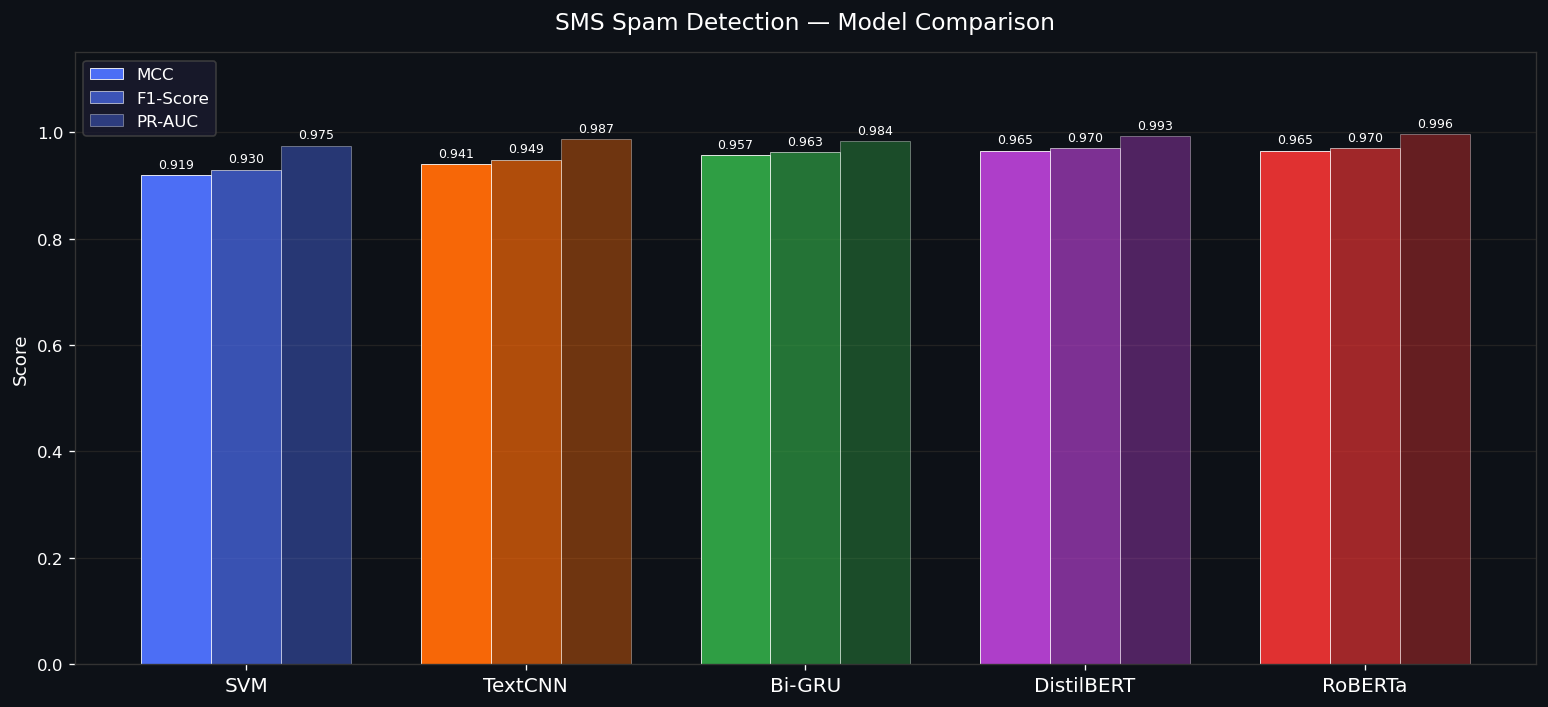

In [40]:
models  = list(ALL_RESULTS.keys())
x       = np.arange(len(models))
width   = 0.25
metrics_list = [("MCC","mcc"),("F1-Score","f1"),("PR-AUC","pr_auc")]
alphas  = [1.0, 0.70, 0.42]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

for i, ((label, key), alpha) in enumerate(zip(metrics_list, alphas)):
    vals = [ALL_RESULTS[m]["metrics"].get(key) or 0 for m in models]
    bars = ax.bar(x+(i-1)*width, vals, width, label=label,
                  color=[PALETTE[m] for m in models],
                  alpha=alpha, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7.5, color="white")

ax.set_xticks(x)
ax.set_xticklabels(models, color="white", fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", color="white", fontsize=11)
ax.set_title("SMS Spam Detection — Model Comparison",
             color="white", fontsize=14, pad=14)
ax.tick_params(colors="white")
ax.spines[:].set_color("#333")
ax.yaxis.grid(True, color="#222", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend([l for l,_ in metrics_list],
          facecolor="#1A1A2E", edgecolor="#444",
          labelcolor="white", fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"comparison.png"),
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

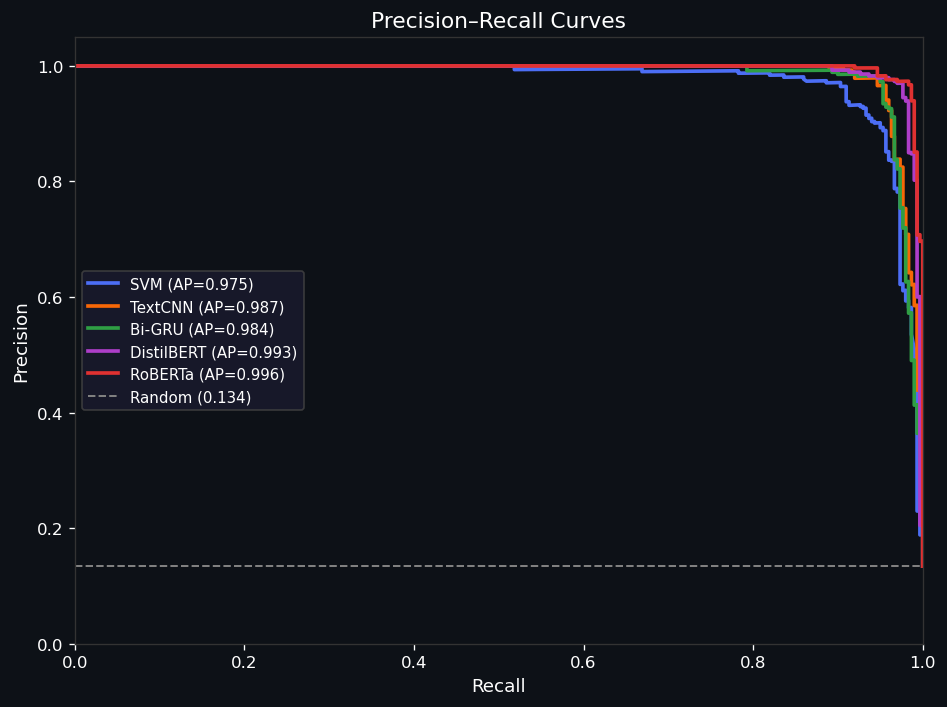

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

for name, res in ALL_RESULTS.items():
    y_true = np.array(res["y_true"])
    y_prob = np.array(res["y_prob"])
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})",
            color=PALETTE[name], linewidth=2.2)

spam_rate = y_test.mean()
ax.axhline(spam_rate, color="gray", linestyle="--",
           linewidth=1.2, label=f"Random ({spam_rate:.3f})")
ax.set_xlabel("Recall",    color="white", fontsize=11)
ax.set_ylabel("Precision", color="white", fontsize=11)
ax.set_title("Precision–Recall Curves", color="white", fontsize=13)
ax.tick_params(colors="white")
ax.spines[:].set_color("#333")
ax.set_xlim(0,1); ax.set_ylim(0, 1.05)
ax.legend(facecolor="#1A1A2E", edgecolor="#444",
          labelcolor="white", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"pr_curves.png"),
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

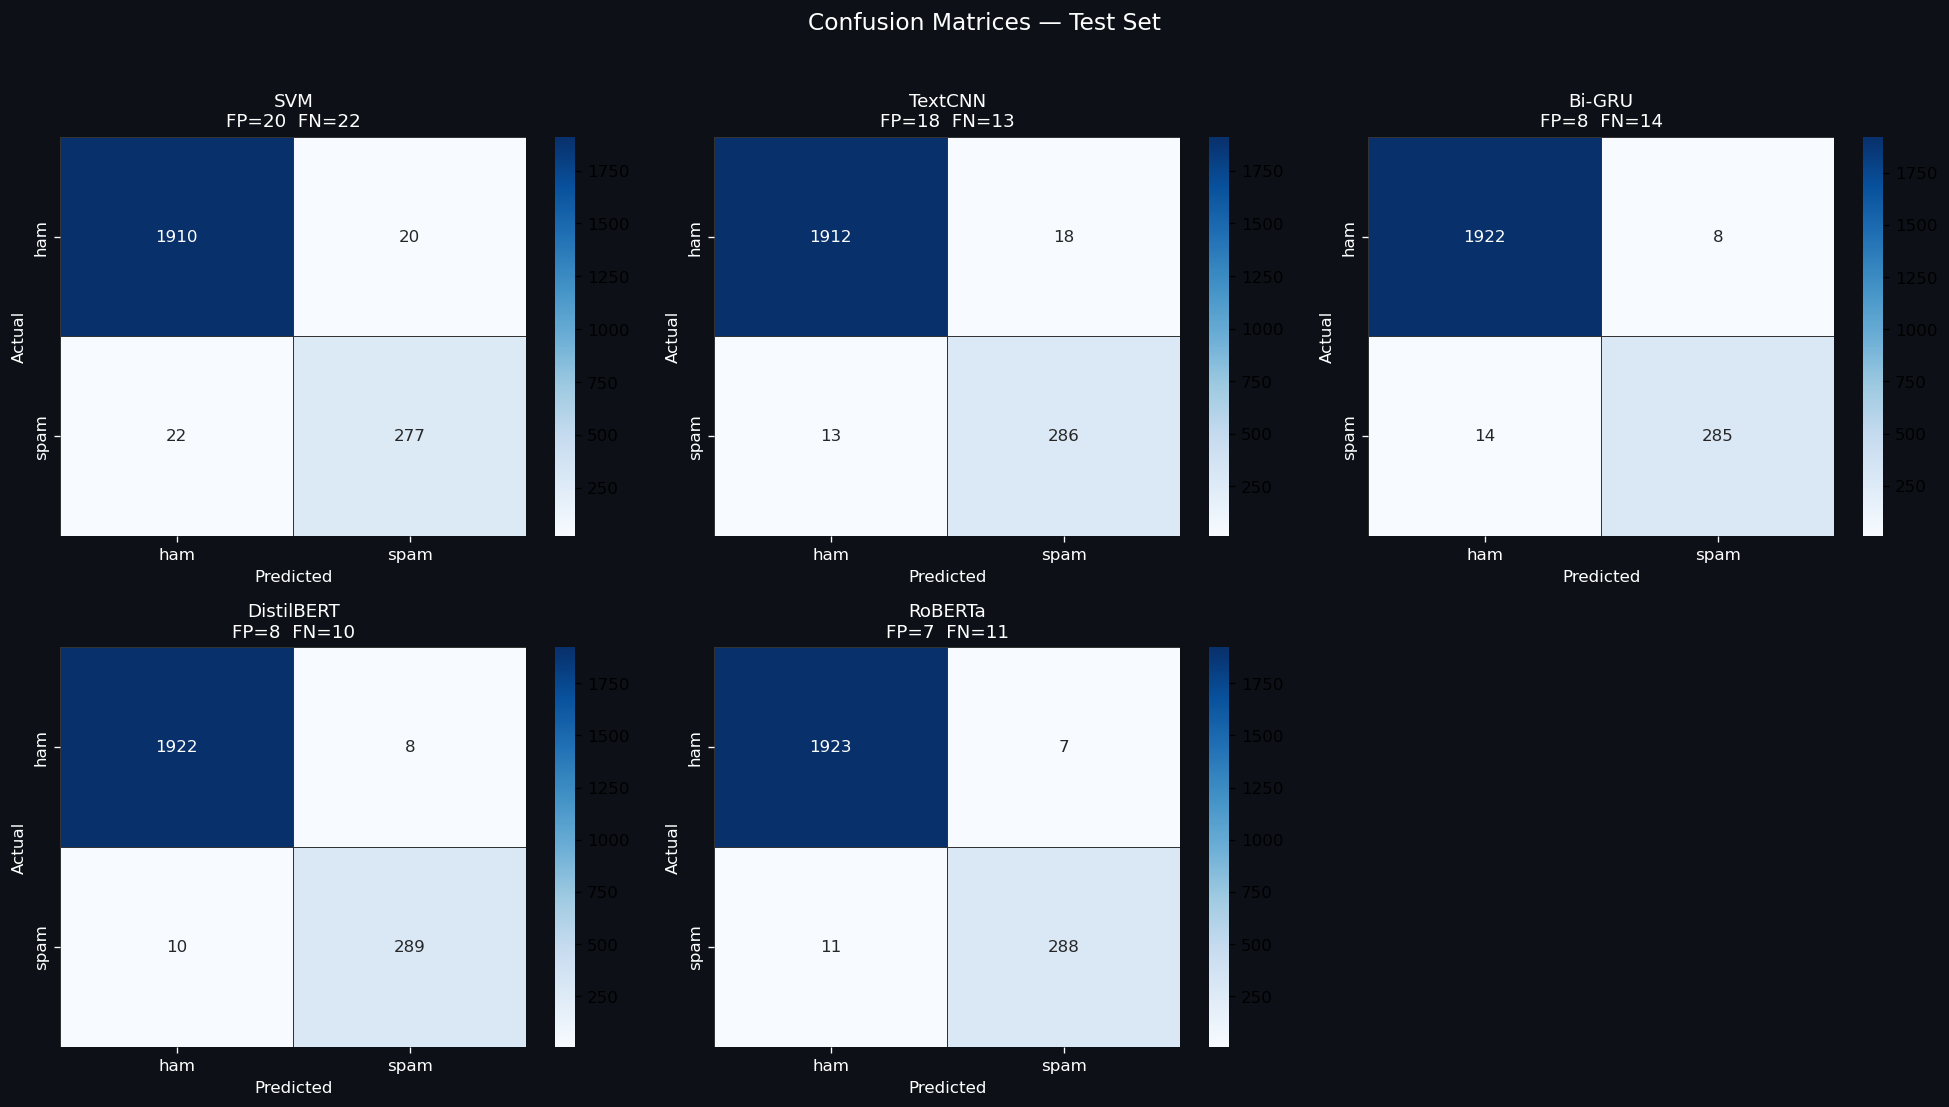

In [42]:
n = len(ALL_RESULTS)
cols = min(n, 3); rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5.5*cols, 4.5*rows))
fig.patch.set_facecolor("#0D1117")
axes = np.array(axes).flatten()

for ax, (name, res) in zip(axes, ALL_RESULTS.items()):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["ham","spam"], yticklabels=["ham","spam"],
                linewidths=0.5, linecolor="#333")
    ax.set_title(f"{name}\nFP={fp}  FN={fn}", color="white", fontsize=11)
    ax.set_xlabel("Predicted", color="white")
    ax.set_ylabel("Actual",    color="white")
    ax.tick_params(colors="white")
    ax.set_facecolor("#0D1117")

for ax in axes[n:]: ax.set_visible(False)
plt.suptitle("Confusion Matrices — Test Set",
             color="white", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"confusion_matrices.png"),
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

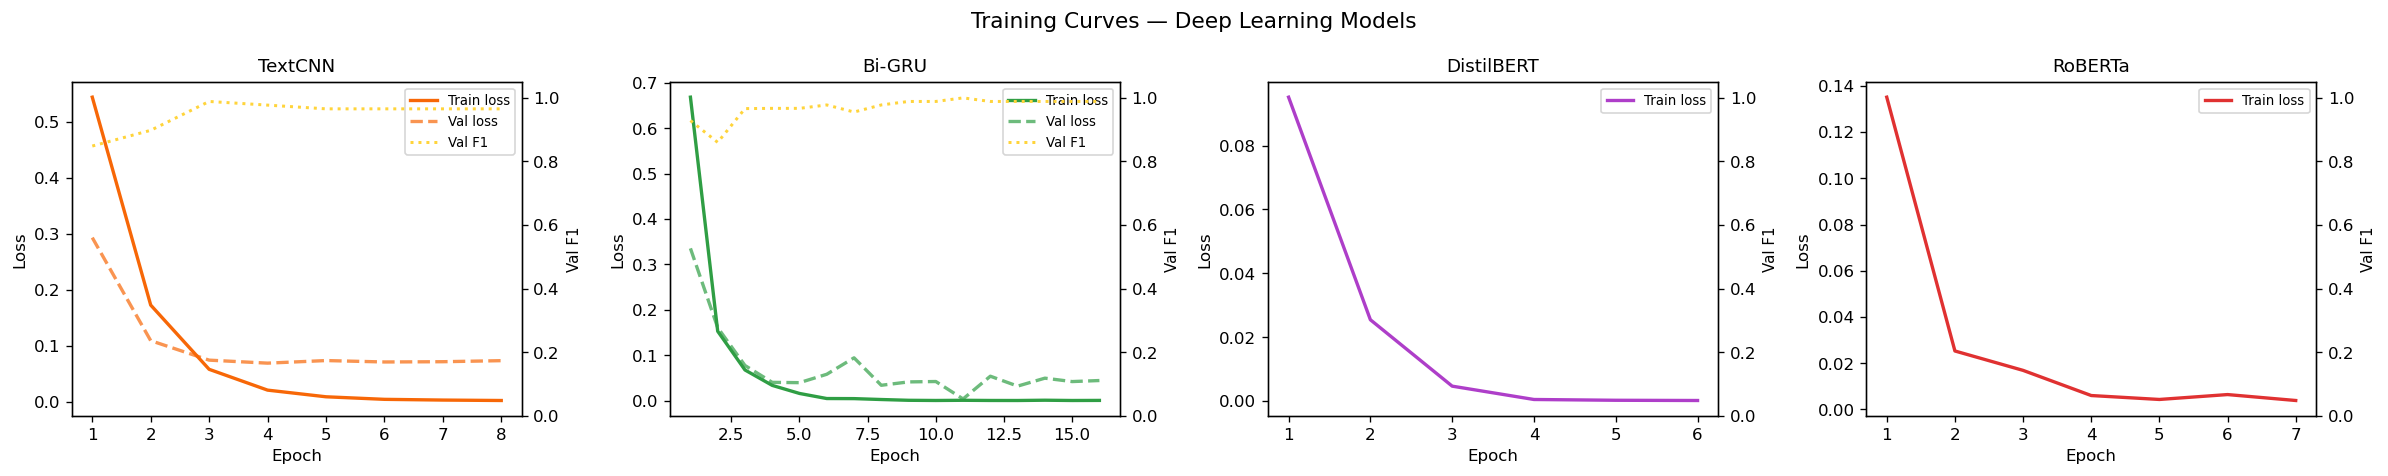

In [43]:
dl_results = {k: v for k, v in ALL_RESULTS.items() if "history" in v}
n = len(dl_results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=False)
if n == 1: axes = [axes]
for ax, (name, res) in zip(axes, dl_results.items()):
    h  = res["history"]
    ep = range(1, len(h["train_loss"]) + 1)
    ax.plot(ep, h["train_loss"], color=PALETTE[name], linewidth=2, label="Train loss")
    if h.get("val_loss"):
        ax.plot(ep, h["val_loss"], color=PALETTE[name], linewidth=2,
                linestyle="--", alpha=0.7, label="Val loss")
    ax2 = ax.twinx()
    if h.get("val_f1"):
        ax2.plot(ep, h["val_f1"], color="#FFD43B", linewidth=1.8,
                 linestyle=":", label="Val F1")
    ax2.set_ylabel("Val F1", fontsize=9); ax2.set_ylim(0, 1.05)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    l1, lb1 = ax.get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, fontsize=8, loc="upper right")
plt.suptitle("Training Curves — Deep Learning Models", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"training_curves.png"),
            dpi=130, bbox_inches="tight")
plt.show()

---
## Section 11 — Discussion & Conclusions
### Summary
- SVM provides a strong, fast baseline using TF-IDF bigrams
- TextCNN captures discriminative n-gram patterns effectively
- Bi-GRU leverages sequential context with attention
- DistilBERT and RoBERTa bring contextual understanding via self-attention
- Weighted loss functions address the ~13.4% spam class imbalance across all models


In [44]:
print("         FINAL TEST SET RESULTS SUMMARY")
print(f"  {'Model':<14} {'MCC':>8} {'F1':>8} {'PR-AUC':>10}")
for name, res in ALL_RESULTS.items():
    m  = res["metrics"]
    pr = m["pr_auc"] or 0.0
    print(f"  {name:<14} {m['mcc']:8.4f} {m['f1']:8.4f} {pr:10.4f}")

print(f"\nOutputs saved to: ./{RESULTS_DIR}/")
for f in ["metrics.json", "01_eda.png", "comparison.png",
          "pr_curves.png", "confusion_matrices.png", "training_curves.png"]:
    status = "✓" if os.path.exists(os.path.join(RESULTS_DIR, f)) else "✗"
    print(f"  {status}  {f}")

         FINAL TEST SET RESULTS SUMMARY
  Model               MCC       F1     PR-AUC
  SVM              0.9187   0.9295     0.9747
  TextCNN          0.9406   0.9486     0.9866
  Bi-GRU           0.9572   0.9628     0.9836
  DistilBERT       0.9651   0.9698     0.9926
  RoBERTa          0.9651   0.9697     0.9963

Outputs saved to: ./results/
  ✓  metrics.json
  ✓  01_eda.png
  ✓  comparison.png
  ✓  pr_curves.png
  ✓  confusion_matrices.png
  ✓  training_curves.png
